# Step 8 - Gap Rate and Reconstruction Quality Monitoring
This notebook reviews the saved monitoring outputs for coverage and model drift.
For normal review, keep it on saved outputs and rebuild monitoring only when you need fresh metrics.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks','src') else Path.cwd()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

STEP8_ROOT = PROJECT_ROOT / 'artifacts' / 'step8_monitoring'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print(f'Project root: {PROJECT_ROOT}')

Project root: c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version


In [2]:
# Run step 8 (or load existing results)
RUN_MONITORING = not (STEP8_ROOT / 'monitoring_summary.json').exists()

if RUN_MONITORING:
    from aero_fusion.step8_monitoring import run_step8_monitoring
    summary = run_step8_monitoring(verbose=True)
else:
    summary = json.loads((STEP8_ROOT / 'monitoring_summary.json').read_text())
    print(json.dumps(summary, indent=2))

{
  "months_covered": 23,
  "total_flights": 1523,
  "date_range": {
    "first": "2023-07",
    "last": "2025-08"
  },
  "overall_gru": {
    "mean_improvement_pct": 28.965328370335342,
    "median_improvement_pct": 46.78022754763535
  },
  "alerts": [
    {
      "type": "LOW_COVERAGE",
      "month": "2023-09",
      "message": "Only 6 segments (mean=66). Possible ADS-C coverage gap.",
      "severity": "WARNING"
    },
    {
      "type": "LOW_COVERAGE",
      "month": "2024-02",
      "message": "Only 16 segments (mean=66). Possible ADS-C coverage gap.",
      "severity": "WARNING"
    },
    {
      "type": "LOW_COVERAGE",
      "month": "2024-09",
      "message": "Only 15 segments (mean=66). Possible ADS-C coverage gap.",
      "severity": "WARNING"
    },
    {
      "type": "LOW_COVERAGE",
      "month": "2025-06",
      "message": "Only 9 segments (mean=66). Possible ADS-C coverage gap.",
      "severity": "WARNING"
    },
    {
      "type": "LOW_COVERAGE",
      "month": "

In [3]:
# Load monthly tables
ds = pd.read_csv(STEP8_ROOT / 'dataset_stats_monthly.csv')
gru_m = pd.read_csv(STEP8_ROOT / 'gru_errors_monthly.csv') if (STEP8_ROOT / 'gru_errors_monthly.csv').exists() else pd.DataFrame()

print(f"Dataset stats: {len(ds)} months")
print(f"GRU monthly errors: {len(gru_m)} months")
display(ds.head())

Dataset stats: 23 months
GRU monthly errors: 22 months


,month,n_segments,n_unique_aircraft,mean_gap_min,median_gap_min,mean_adsc_points,gap_rate_proxy
0,2023-07,86,66,72.334109,64.175000,6.662791,0.554839
1,2023-08,42,35,78.790873,74.275000,4.166667,0.270968
2,2023-09,6,6,74.958333,71.366667,3.833333,0.038710
3,2023-10,141,101,76.638298,69.350000,7.851064,0.909677
4,2023-11,155,115,74.781720,69.366667,5.864516,1.000000


## Flight Coverage Per Month
This section tracks how many usable flights are available over time.
It is the basic coverage signal behind every later reconstruction metric.


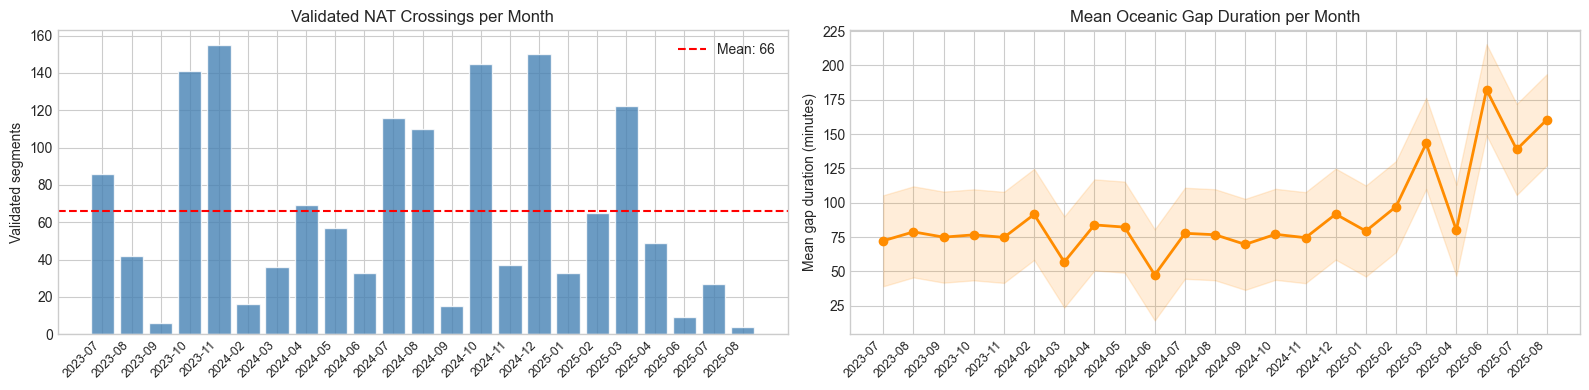

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Segment count per month
x = range(len(ds))
axes[0].bar(x, ds['n_segments'], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(ds['n_segments'].mean(), color='red', linestyle='--',
                label=f'Mean: {ds["n_segments"].mean():.0f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ds['month'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Validated segments')
axes[0].set_title('Validated NAT Crossings per Month')
axes[0].legend()

# Mean gap duration per month
axes[1].plot(x, ds['mean_gap_min'], '-o', color='darkorange', lw=2, ms=6)
axes[1].fill_between(x, ds['mean_gap_min'] - ds['mean_gap_min'].std(),
                         ds['mean_gap_min'] + ds['mean_gap_min'].std(),
                         alpha=0.15, color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ds['month'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Mean gap duration (minutes)')
axes[1].set_title('Mean Oceanic Gap Duration per Month')

plt.tight_layout()
plt.savefig(STEP8_ROOT / 'coverage_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Reconstruction Quality Trend Over Time
These plots show whether reconstruction error is stable or drifting by month.
They are the main check for model health after deployment.


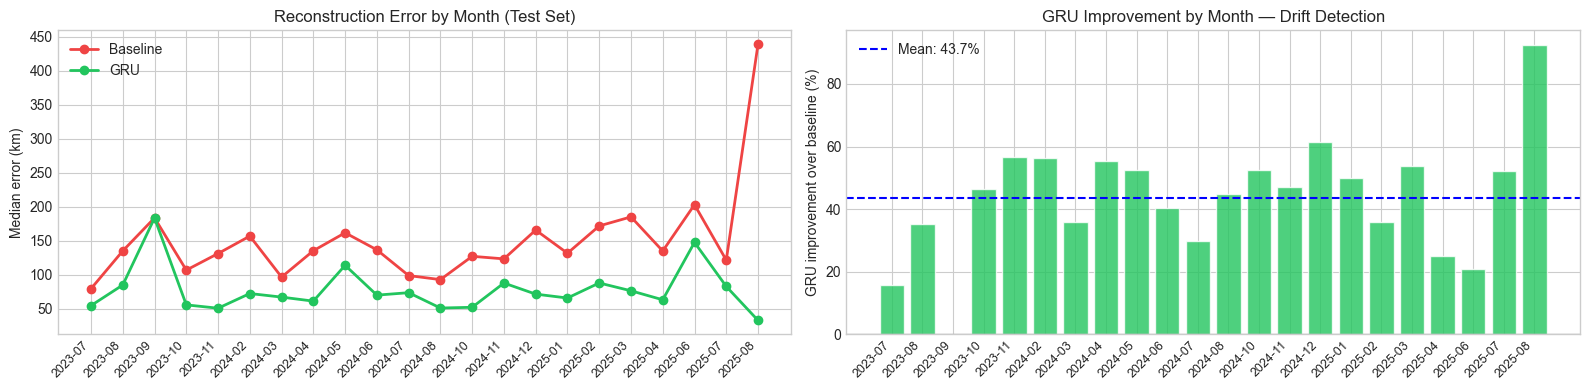

Overall GRU improvement: 43.7% mean across months
Std dev across months:   18.9% (lower = more stable)


In [5]:
if gru_m.empty:
    print('GRU monthly data not available. Run step 5 first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    x = range(len(gru_m))

    # Error trend
    axes[0].plot(x, gru_m['bl_median_km'],  '-o', color='#ef4444', lw=2, ms=6, label='Baseline')
    axes[0].plot(x, gru_m['gru_median_km'], '-o', color='#22c55e', lw=2, ms=6, label='GRU')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(gru_m['month'], rotation=45, ha='right', fontsize=9)
    axes[0].set_ylabel('Median error (km)')
    axes[0].set_title('Reconstruction Error by Month (Test Set)')
    axes[0].legend()

    # Improvement trend
    colors = ['#22c55e' if v > 0 else '#ef4444' for v in gru_m['improvement_median']]
    axes[1].bar(x, gru_m['improvement_median'], color=colors, alpha=0.8, edgecolor='white')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].axhline(gru_m['improvement_median'].mean(), color='blue', linestyle='--',
                    label=f'Mean: {gru_m["improvement_median"].mean():.1f}%')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(gru_m['month'], rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel('GRU improvement over baseline (%)')
    axes[1].set_title('GRU Improvement by Month — Drift Detection')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(STEP8_ROOT / 'quality_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Overall GRU improvement: {gru_m['improvement_median'].mean():.1f}% mean across months")
    print(f"Std dev across months:   {gru_m['improvement_median'].std():.1f}% (lower = more stable)")

## Three-Method Comparison Across Months
This view compares baseline, Kalman, and GRU performance on the same monthly slices.
It makes method ranking changes easy to spot.


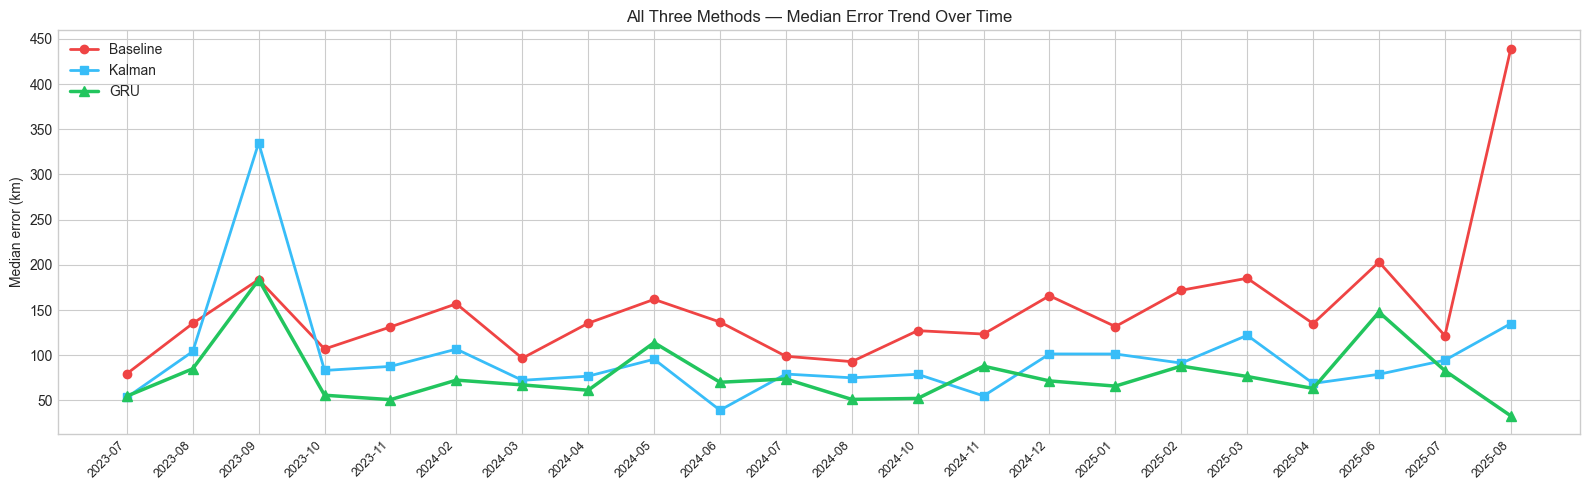

In [6]:
kf_path = PROJECT_ROOT / 'artifacts' / 'step5_kalman' / 'per_flight_metrics_test.parquet'
if not kf_path.exists():
    kf_path = PROJECT_ROOT / 'artifacts' / 'step3b_kalman' / 'catalog' / 'kf_flights.parquet'

if kf_path.exists() and not gru_m.empty:
    kf_df = pd.read_parquet(kf_path)
    err_col = next((c for c in ['kalman_mean_error_km','kf_mean_error_km'] if c in kf_df.columns), None)

    if err_col:
        kf_df['month'] = kf_df['segment_id'].apply(lambda s: pd.Timestamp(str(s)[:8]).strftime('%Y-%m') if len(str(s))>=8 else None)
        kf_m = kf_df.dropna(subset=['month']).groupby('month').agg(kf_median=(err_col,'median')).reset_index()

        # Merge all methods
        merged = gru_m[['month','gru_median_km','bl_median_km']].merge(kf_m, on='month', how='inner')

        fig, ax = plt.subplots(figsize=(16, 5))
        x = range(len(merged))
        ax.plot(x, merged['bl_median_km'],  '-o', color='#ef4444', lw=2, ms=6, label='Baseline')
        ax.plot(x, merged['kf_median'],     '-s', color='#38bdf8', lw=2, ms=6, label='Kalman')
        ax.plot(x, merged['gru_median_km'], '-^', color='#22c55e', lw=2.5, ms=7, label='GRU')
        ax.set_xticks(x)
        ax.set_xticklabels(merged['month'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Median error (km)')
        ax.set_title('All Three Methods — Median Error Trend Over Time')
        ax.legend()
        plt.tight_layout()
        plt.savefig(STEP8_ROOT / 'three_method_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Kalman data not available — showing GRU vs baseline only')

## Alerts Summary
This section summarizes any coverage or quality thresholds that were breached.
Treat it as the compact monitoring status page for the project.


In [7]:
alerts = summary.get('alerts', [])
print(f"Total alerts: {len(alerts)}")
print()
if alerts:
    for a in alerts:
        icon = '⚠️' if a['severity']=='WARNING' else 'ℹ️'
        print(f"{icon} [{a['type']}] {a['month']}: {a['message']}")
else:
    print('✅ No alerts — data coverage and model quality are stable across all months.')

Total alerts: 9

⚠️ [LOW_COVERAGE] 2023-09: Only 6 segments (mean=66). Possible ADS-C coverage gap.
⚠️ [LOW_COVERAGE] 2024-02: Only 16 segments (mean=66). Possible ADS-C coverage gap.
⚠️ [LOW_COVERAGE] 2024-09: Only 15 segments (mean=66). Possible ADS-C coverage gap.
⚠️ [LOW_COVERAGE] 2025-06: Only 9 segments (mean=66). Possible ADS-C coverage gap.
⚠️ [LOW_COVERAGE] 2025-08: Only 4 segments (mean=66). Possible ADS-C coverage gap.
⚠️ [MODEL_DRIFT] 2023-07: GRU improvement only -7.6% (threshold=5.0%). Possible model drift.
⚠️ [MODEL_DRIFT] 2023-08: GRU improvement only -7.8% (threshold=5.0%). Possible model drift.
⚠️ [MODEL_DRIFT] 2025-04: GRU improvement only -27.2% (threshold=5.0%). Possible model drift.
ℹ️ [GAP_DURATION_TREND] overall: Average gap duration increased from 74min to 109min. Possible ADS-C reporting change.


## Summary
The monitoring outputs should stay quiet during stable periods and surface clear regressions when the data shifts.
Keep the notebook on saved outputs unless you intentionally rerun Step 8.


In [8]:
print('='*60)
print('STEP 8 — MONITORING SUMMARY')
print('='*60)
print(f"  Months monitored   : {summary['months_covered']}")
print(f"  Total flights      : {summary['total_flights']:,}")
print(f"  Date range         : {summary['date_range']['first']} → {summary['date_range']['last']}")
if summary['overall_gru']['mean_improvement_pct']:
    print(f"  GRU improvement    : {summary['overall_gru']['mean_improvement_pct']:.1f}% mean")
print(f"  Alerts             : {summary['n_alerts']}")
print()
print('  Saved outputs:')
for f in ['coverage_trend.png','quality_trend.png','three_method_trend.png',
          'dataset_stats_monthly.csv','gru_errors_monthly.csv']:
    p = STEP8_ROOT / f
    print(f"  {'✅' if p.exists() else '⬜'} {f}")
print('='*60)

STEP 8 — MONITORING SUMMARY
  Months monitored   : 23
  Total flights      : 1,523
  Date range         : 2023-07 → 2025-08
  GRU improvement    : 29.0% mean
  Alerts             : 9

  Saved outputs:
  ✅ coverage_trend.png
  ✅ quality_trend.png
  ✅ three_method_trend.png
  ✅ dataset_stats_monthly.csv
  ✅ gru_errors_monthly.csv
